## OpenCV Bootcamp

The free course is available at [OpenCV University](https://courses.opencv.org/courses/course-v1:OpenCV+Bootcamp+CV0/course/)

## Basic Image Enhancement Using Mathematical Operations

Image Processing techniques take advantage of mathematical operations to achieve different results. Most often we arrive at an enhanced version of the image using some basic operations. We will take a look at some of the fundamental operations often used in computer vision pipelines. In this notebook we will cover:

- Arithmetic Operations like addition, multiplication
- Thresholding & Masking
- Bitwise Operations like OR, AND, XOR

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

from IPython.display import Image

%matplotlib inline

### Download Assets

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assets....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)
    
    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)

In [ ]:
URL = r"https://www.dropbox.com/s/0oe92zziik5mwhf/opencv_bootcamp_assets_NB4.zip?dl=1"

asset_zip_path = os.path.join(r"../assets", "opencv_bootcamp_assets_NB4.zip")

# Download if assest ZIP does not exists. 
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

### Original image

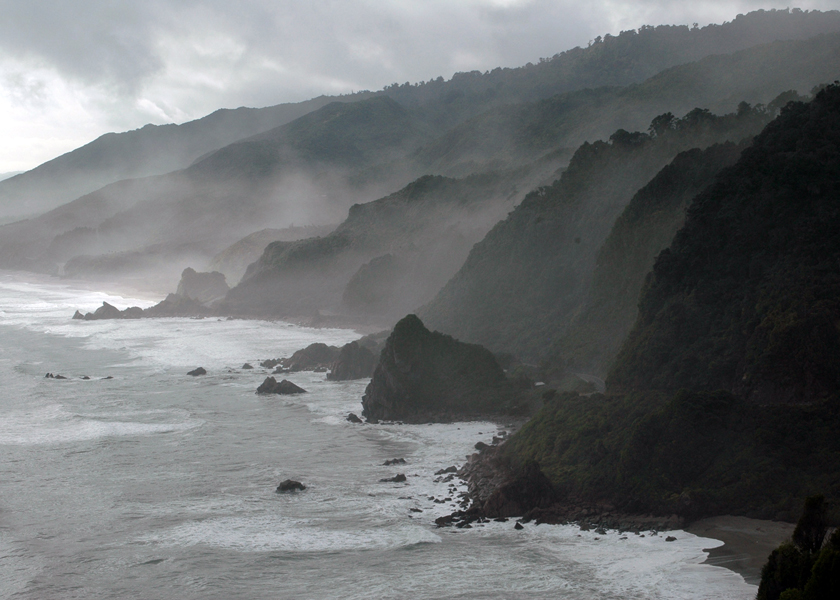

In [4]:
img_bgr = cv2.imread("../assets/New_Zealand_Coast.jpg", cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display 18x18 pixel image.
Image(filename="../assets/New_Zealand_Coast.jpg")

### Addition or Brightness

The first operation we discuss is simple addition of images. This results in increasing or decreasing the brightness of the image since we are eventually increasing or decreasing the intensity values of each pixel by the same amount. So, this will result in a global increase/decrease in brightness.

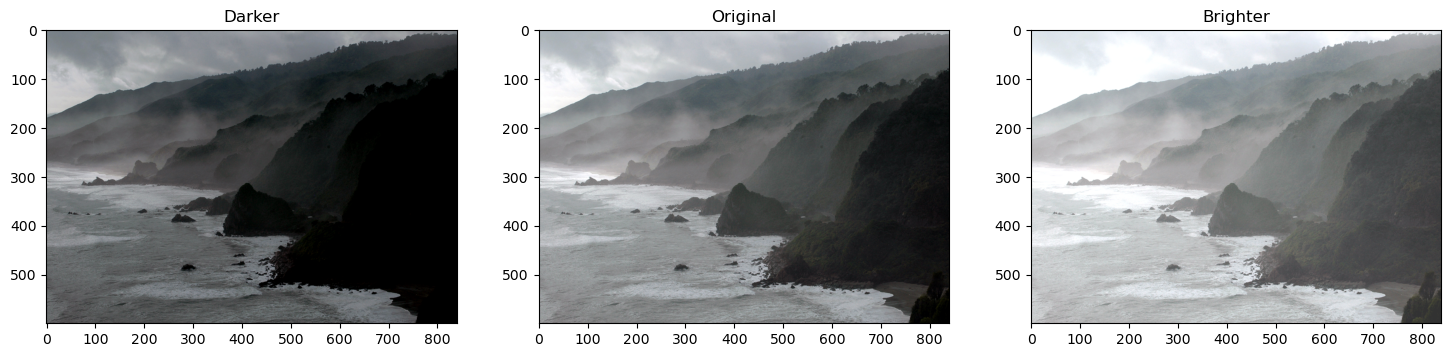

In [5]:
matrix = np.ones(img_rgb.shape, dtype="uint8") * 50

img_rgb_brighter = cv2.add(img_rgb, matrix)
img_rgb_darker   = cv2.subtract(img_rgb, matrix)


# Show the images
plt.figure(figsize=[18, 5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Darker");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Brighter");

### Multiplication or Contrast

Just like addition can result in brightness change, multiplication can be used to improve the contrast of the image.

Contrast is the difference in the intensity values of the pixels of an image. Multiplying the intensity values with a constant can make the difference larger or smaller ( if multiplying factor is < 1 ).

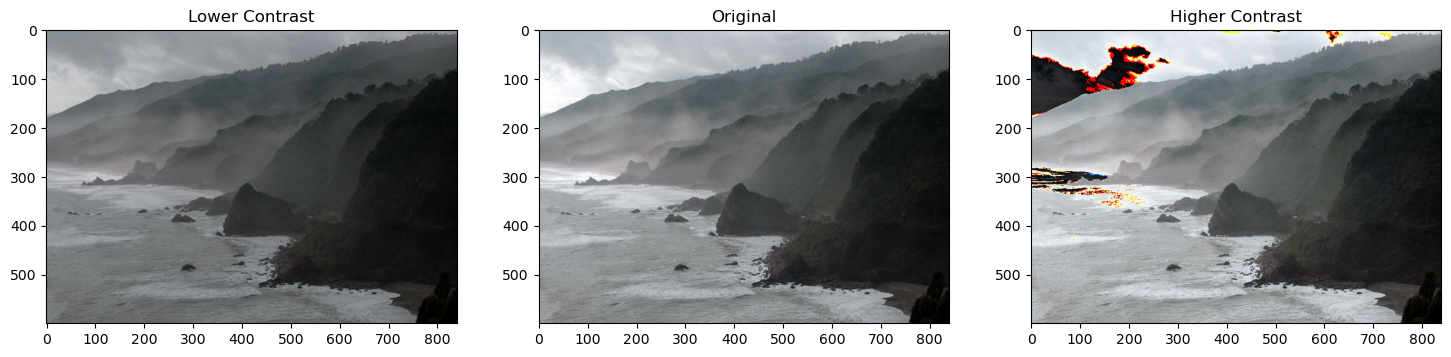

In [6]:
matrix1 = np.ones(img_rgb.shape) * 0.8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_darker   = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_brighter = np.uint8(cv2.multiply(np.float64(img_rgb), matrix2))

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_darker);  plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);         plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_brighter);plt.title("Higher Contrast");

#### What happened?

Can you see the weird colors in some areas of the image after multiplication?

The issue is that after multiplying, the values which are already high, are becoming greater than 255. Thus, the overflow issue. How do we overcome this?

#### Handling Overflow using `np.clip`

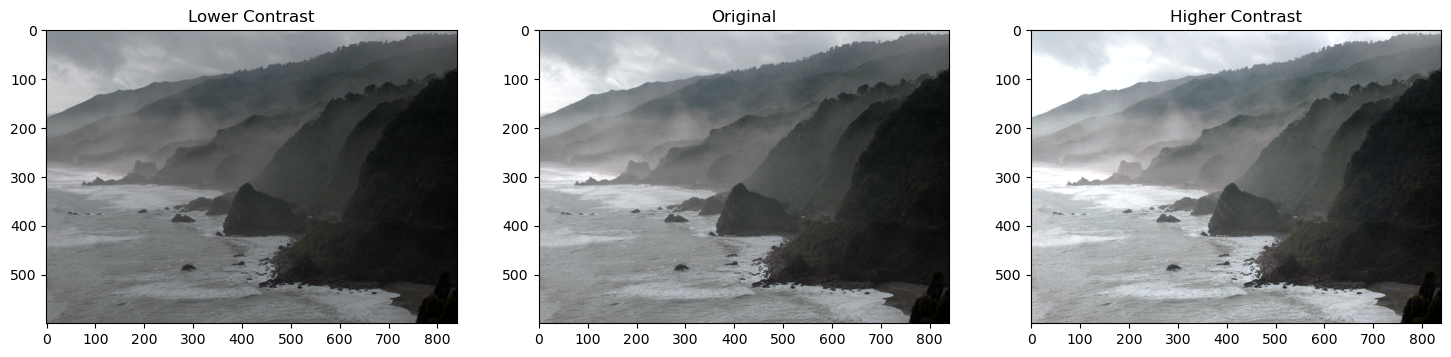

In [7]:
matrix1 = np.ones(img_rgb.shape) * 0.8
matrix2 = np.ones(img_rgb.shape) * 1.2

img_rgb_lower  = np.uint8(cv2.multiply(np.float64(img_rgb), matrix1))
img_rgb_higher = np.uint8(np.clip(cv2.multiply(np.float64(img_rgb), matrix2), 0, 255))

# Show the images
plt.figure(figsize=[18,5])
plt.subplot(131); plt.imshow(img_rgb_lower); plt.title("Lower Contrast");
plt.subplot(132); plt.imshow(img_rgb);       plt.title("Original");
plt.subplot(133); plt.imshow(img_rgb_higher);plt.title("Higher Contrast");

#### ⚠️ Overflow Handling: `np.clip` vs. `np.uint8`

When manipulating pixel intensities (such as increasing brightness or contrast via multiplication/addition), the newly calculated values frequently exceed the maximum 8-bit limit ($255$). 

Direct type casting using only `np.uint8()` **does not** saturate the values. Understanding the difference in behavior is critical:

1. **Modulo Arithmetic (`np.uint8`)**:
   * The `uint8` data type strictly stores values between $0$ and $255$.
   * When a value greater than $255$ is cast directly via NumPy, a wrap-around effect (memory overflow) occurs. The value loops back based on the mathematical operation: $value \pmod{256}$.
   * **Example**: A pixel with a calculated value of $260$ becomes $4$ ($260 - 256$). Visually, a region that should be bright white turns into a dark pixel, generating severe image artifacts.

2. **Saturation Clipping (`np.clip`)**:
   * The `np.clip(array, 0, 255)` function must be applied **before** casting the data type.
   * It constrains the data within the specified range. Any value above $255$ is clamped to $255$ (pure white), and any value below $0$ is clamped to $0$ (pure black).

> 💡 **OpenCV Note**: Native functions like `cv2.add()` and `cv2.multiply()` automatically implement saturation clipping when operating directly on arrays with identical data types. However, when performing arithmetic using standard Python/NumPy operators (`*`, `+`) or when handling intermediate type conversions (`float64`), explicitly calling `np.clip()` is mandatory to preserve visual integrity.


#### Practical Verification: Simulating the Modulo Error

To better understand why `np.clip` is mathematically required, let's run a controlled experiment using a simulated row of pixels. 

##### Goal of this Simulation:
1. Create a dummy pixel array with high intensities ($200$ to $250$).
2. Apply a contrast factor ($1.1$) that forces the new values to exceed the $255$ threshold ($220$ to $275$).
3. Compare the visual and numerical degradation caused by direct `np.uint8` casting against the clean output of `np.clip`.

Run the cell below to see the exact numerical output and the resulting pixel artifacts:

Calculated Values (Float):    [[220. 231. 242. 253. 264. 275.]]
Direct np.uint8 Result:       [[220 231 242 253   8  19]]
np.clip + np.uint8 Result:    [[220 231 242 253 255 255]]


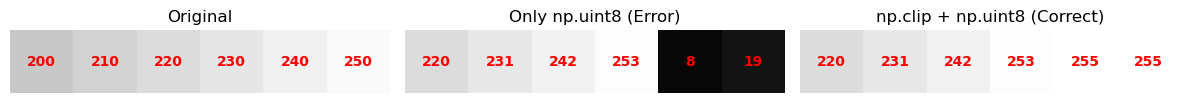

In [8]:
# 1. Create a row of pixels simulating a gradient that will exceed the 255 limit
# Original values ranging from 200 to 250
original_pixels = np.array([[200, 210, 220, 230, 240, 250]], dtype=np.float64)

# 2. Apply contrast gain (Multiplication by 1.1)
# Resulting values will range from 220 to 275 (exceeding 255!)
modified_pixels = original_pixels * 1.1

# 3. INCORRECT approach: Direct cast to uint8 (Wrap-around / Modulo effect)
modulo_result = modified_pixels.astype(np.uint8)

# 4. CORRECT approach: Clipping before casting to uint8 (Saturation)
saturated_result = np.clip(modified_pixels, 0, 255).astype(np.uint8)

# --- Print numerical results ---
print("Calculated Values (Float):   ", modified_pixels)
print("Direct np.uint8 Result:      ", modulo_result)
print("np.clip + np.uint8 Result:   ", saturated_result)

# --- Visual Demonstration ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Original Plot
axes[0].imshow(original_pixels, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original")
for i in range(original_pixels.shape[1]):
    axes[0].text(i, 0, f"{int(original_pixels[0, i])}", ha="center", va="center", color="red", weight="bold")

# Incorrect Plot (Modulo / Artifacts)
axes[1].imshow(modulo_result, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Only np.uint8 (Error)")
for i in range(modulo_result.shape[1]):
    axes[1].text(i, 0, f"{modulo_result[0, i]}", ha="center", va="center", color="red", weight="bold")

# Correct Plot (Clip / Saturated)
axes[2].imshow(saturated_result, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("np.clip + np.uint8 (Correct)")
for i in range(saturated_result.shape[1]):
    axes[2].text(i, 0, f"{saturated_result[0, i]}", ha="center", va="center", color="red", weight="bold")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


### Image Thresholding

Binary Images have a lot of use cases in Image Processing. One of the most common use cases is that of creating masks. Image Masks allow us to process on specific parts of an image keeping the other parts intact. Image Thresholding is used to create Binary Images from grayscale images. You can use different thresholds to create different binary images from the same original image.

#### Function Syntax

retval, dst = cv2.threshold( src, thresh, maxval, type[, dst] )

    retval: The threshold value calculated or used by the algorithm.

    dst: The output array of the same size and type and the same number of channels as src.

The function has 4 required arguments:

- src: input array (multiple-channel, 8-bit or 32-bit floating point).

- thresh: threshold value.

- maxval: maximum value to use with the THRESH_BINARY and THRESH_BINARY_INV thresholding types.

- type: thresholding type (see ThresholdTypes).

#### Function Syntax

dst = cv.adaptiveThreshold( src, maxValue, adaptiveMethod, thresholdType, blockSize, C[, dst] )
dst Destination image of the same size and the same type as src.

The function has 6 required arguments:

- src: Source 8-bit single-channel image.

- maxValue: Non-zero value assigned to the pixels for which the condition is satisfied

- adaptiveMethod: Adaptive thresholding algorithm to use, see AdaptiveThresholdTypes. The BORDER_REPLICATE | BORDER_ISOLATED is used to process boundaries.

- thresholdType: Thresholding type that must be either THRESH_BINARY or THRESH_BINARY_INV, see ThresholdTypes.

- blockSize: Size of a pixel neighborhood that is used to calculate a threshold value for the pixel: 3, 5, 7, and so on.

- C: Constant subtracted from the mean or weighted mean (see the details below). Normally, it is positive but may be zero or negative as well.

**OpenCV Documentation:** [Documentation link](https://docs.opencv.org/4.5.1/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57https://docs.opencv.org/4.5.1/d7/d4d/tutorial_py_thresholding.html)

(572, 800)


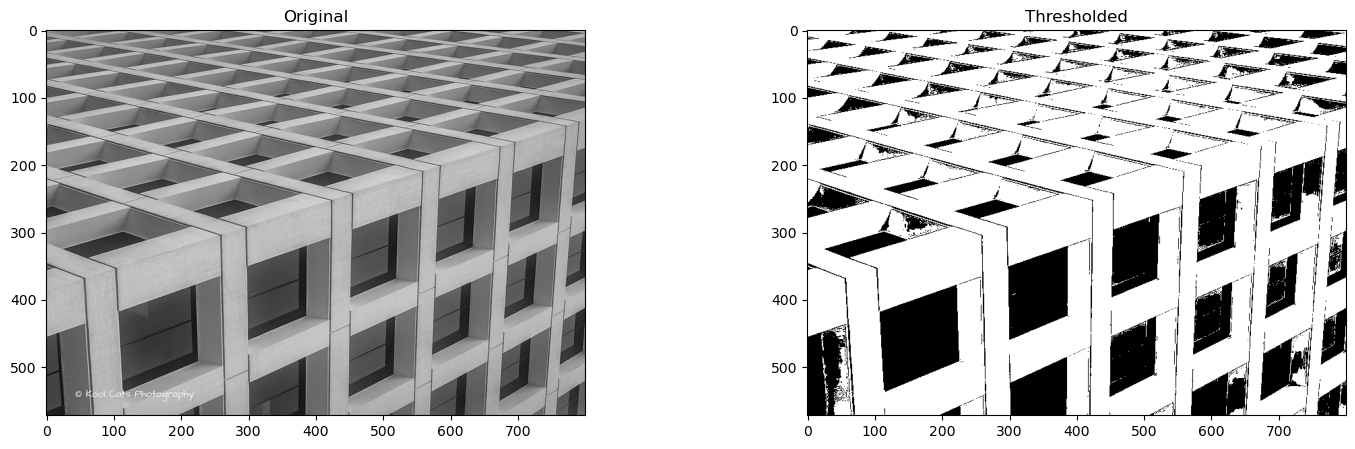

In [9]:
img_read = cv2.imread("../assets/building-windows.jpg", cv2.IMREAD_GRAYSCALE)
retval, img_thresh = cv2.threshold(img_read, 100, 255, cv2.THRESH_BINARY)

# Show the images
plt.figure(figsize=[18, 5])

plt.subplot(121);plt.imshow(img_read, cmap="gray");  plt.title("Original")
plt.subplot(122);plt.imshow(img_thresh, cmap="gray");plt.title("Thresholded")

print(img_thresh.shape)

### Application: Sheet Music Reader

Suppose you wanted to build an application that could read (decode) sheet music. This is similar to Optical Character Recognigition (OCR) for text documents where the goal is to recognize text characters. In either application, one of the first steps in the processing pipeline is to isolate the important information in the image of a document (separating it from the background). This task can be accomplished with thresholding techniques.

Let's take a look at an example.

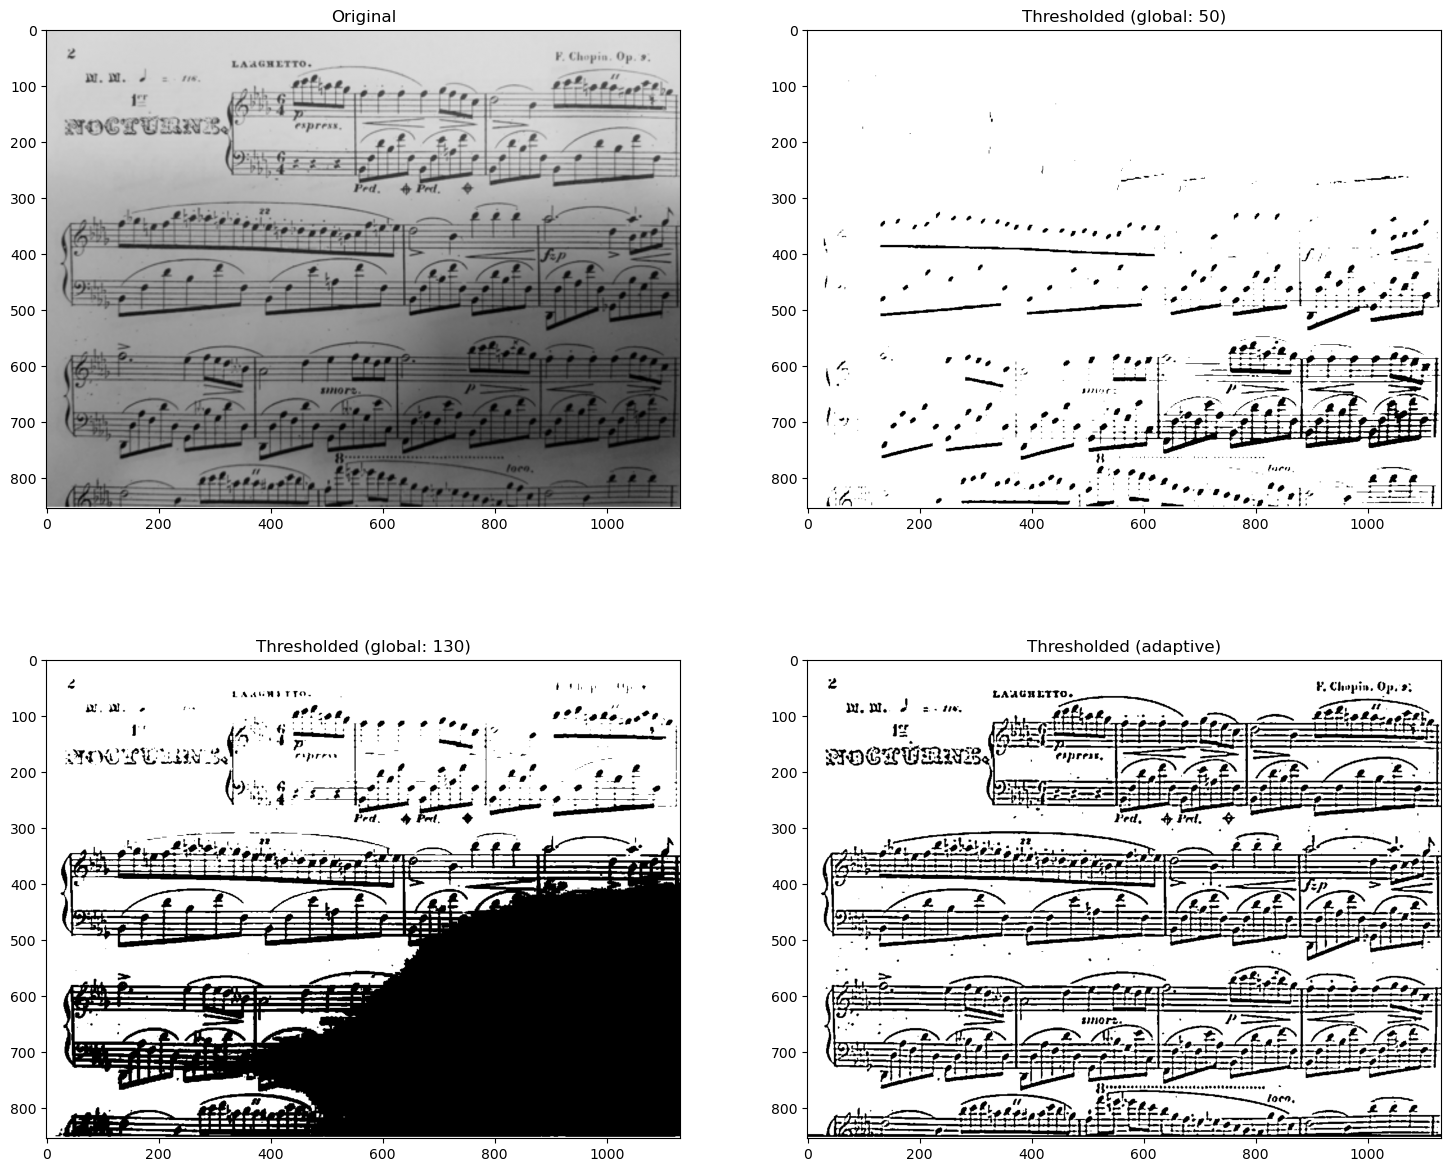

In [10]:
# Read the original image
img_read = cv2.imread("../assets/Piano_Sheet_Music.png", cv2.IMREAD_GRAYSCALE)

# Perform global thresholding
retval, img_thresh_gbl_1 = cv2.threshold(img_read, 50, 255, cv2.THRESH_BINARY)

# Perform global thresholding
retval, img_thresh_gbl_2 = cv2.threshold(img_read, 130, 255, cv2.THRESH_BINARY)

# Perform adaptive thresholding
img_thresh_adp = cv2.adaptiveThreshold(img_read, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 7)

# Show the images
plt.figure(figsize=[18,15])
plt.subplot(221); plt.imshow(img_read,        cmap="gray");  plt.title("Original");
plt.subplot(222); plt.imshow(img_thresh_gbl_1,cmap="gray");  plt.title("Thresholded (global: 50)");
plt.subplot(223); plt.imshow(img_thresh_gbl_2,cmap="gray");  plt.title("Thresholded (global: 130)");
plt.subplot(224); plt.imshow(img_thresh_adp,  cmap="gray");  plt.title("Thresholded (adaptive)");

### Bitwise Operations

#### Function Syntax

Example API for `cv2.bitwise_and()`. Others include: `cv2.bitwise_or()`, `cv2.bitwise_xor()`, `cv2.bitwise_not()`

dst = cv2.bitwise_and( src1, src2[, dst[, mask]] )
dst: Output array that has the same size and type as the input arrays.

The function has 2 required arguments:

- src1: first input array or a scalar.

- src2: second input array or a scalar.

An important optional argument is:

- mask: optional operation mask, 8-bit single channel array, that specifies elements of the output array to be changed.

**OpenCV Documentation**

 [Arithmetic Operations on Images](https://docs.opencv.org/4.5.1/d0/d86/tutorial_py_image_arithmetics.html)

 [bitwise_and(...) function](https://docs.opencv.org/4.5.0/d2/de8/group__core__array.html#ga60b4d04b251ba5eb1392c34425497e14)

(200, 499)


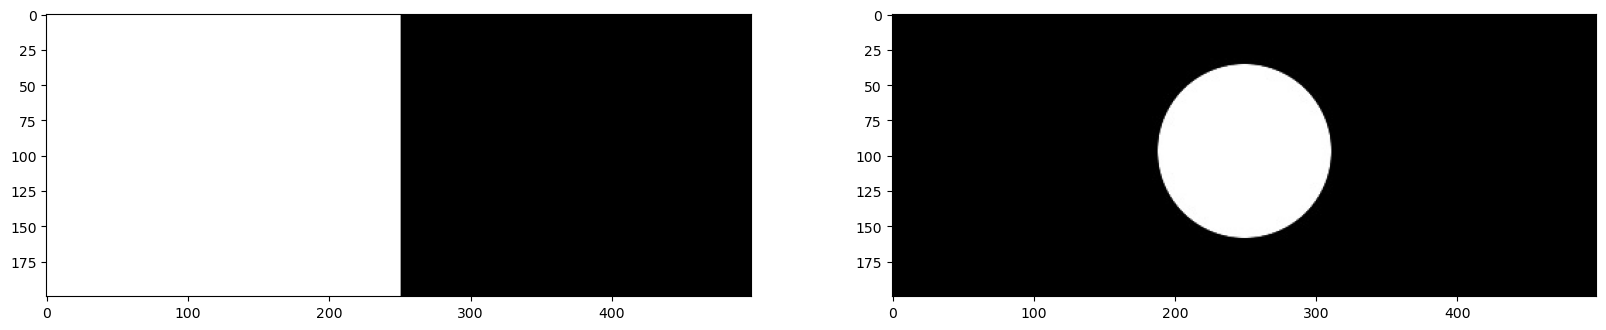

In [11]:
img_rec = cv2.imread("../assets/rectangle.jpg", cv2.IMREAD_GRAYSCALE)

img_cir = cv2.imread("../assets/circle.jpg", cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=[20, 5])
plt.subplot(121);plt.imshow(img_rec, cmap="gray")
plt.subplot(122);plt.imshow(img_cir, cmap="gray")
print(img_rec.shape)

**Summary**

`cv2.bitwise_and`: Keeps pixels that are white in both input images (intersection).

`cv2.bitwise_or`: Keeps pixels that are white in either input image (union).

`cv2.bitwise_xor`: Keeps pixels that are white in only one image, but not both (difference).

`cv2.bitwise_not`: Inverts the image colors, turning white to black and black to white (negation).

### Bitwise AND Operator

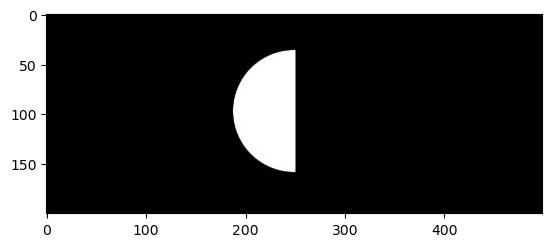

In [12]:
result = cv2.bitwise_and(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray");

### Bitwise OR Operator

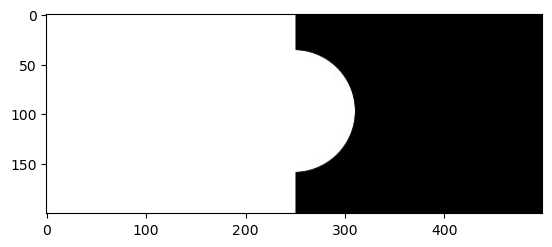

In [13]:
result = cv2.bitwise_or(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray");

### Bitwise XOR Operator

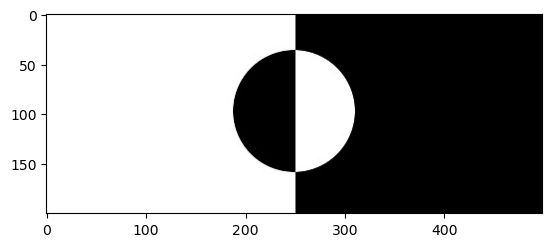

In [14]:
result = cv2.bitwise_xor(img_rec, img_cir, mask=None)
plt.imshow(result, cmap="gray");

### Application: Logo Manipulation

In this section we will show you how to fill in the white lettering of the Coca-Cola logo below with a background image.

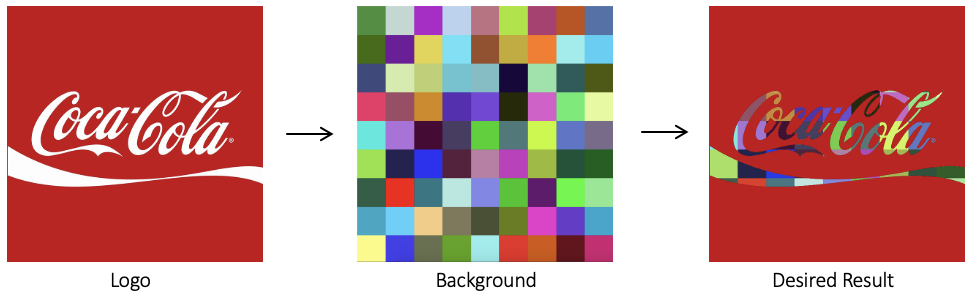

In [15]:
Image(filename='../assets/Logo_Manipulation.png')

### Read Foreground image

(700, 700, 3)


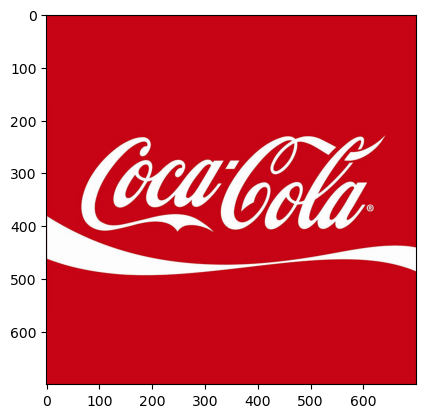

In [16]:
img_bgr = cv2.imread("../assets/coca-cola-logo.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb);

print(img_rgb.shape)

logo_w = img_rgb.shape[0]
logo_h = img_rgb.shape[1]

### Read Background image

(700, 700, 3)


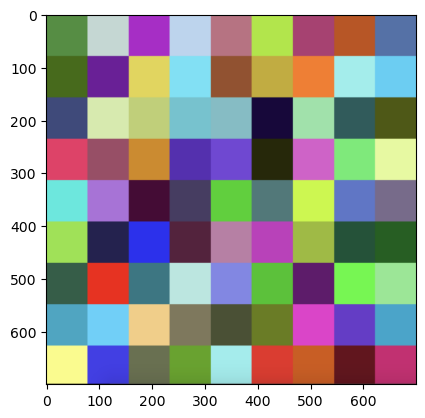

In [17]:
# Read in image of color cheackerboad background
img_background_bgr = cv2.imread("../assets/checkerboard_color.png")
img_background_rgb = cv2.cvtColor(img_background_bgr, cv2.COLOR_BGR2RGB)

# Set desired width (logo_w) and maintain image aspect ratio
aspect_ratio = logo_w / img_background_rgb.shape[1]
dim = (logo_w, int(img_background_rgb.shape[0] * aspect_ratio))

# Resize background image to sae size as logo image
img_background_rgb = cv2.resize(img_background_rgb, dim, interpolation=cv2.INTER_AREA)

plt.imshow(img_background_rgb)
print(img_background_rgb.shape)

### Create Mask for original Image

(700, 700)


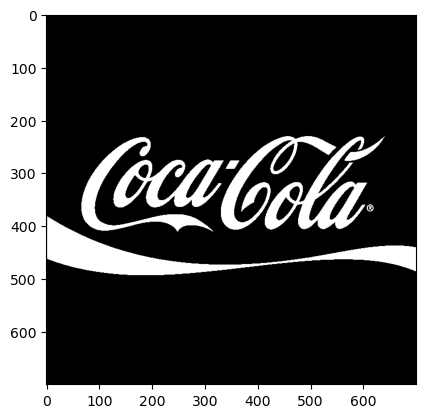

In [18]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Apply global thresholding to create a binary mask of the logo
retval, img_mask = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(img_mask, cmap="gray");
print(img_mask.shape)

### Invert the Mask

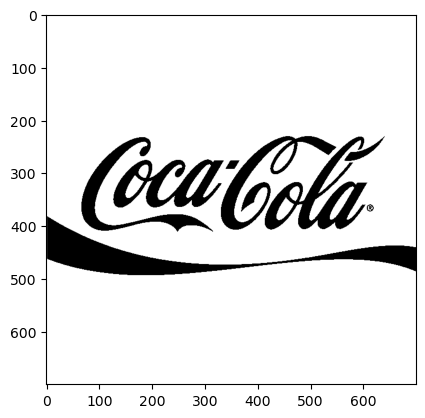

In [19]:
# Create an inverse mask
img_mask_inv = cv2.bitwise_not(img_mask)
plt.imshow(img_mask_inv, cmap="gray");

### Apply background on the Mask

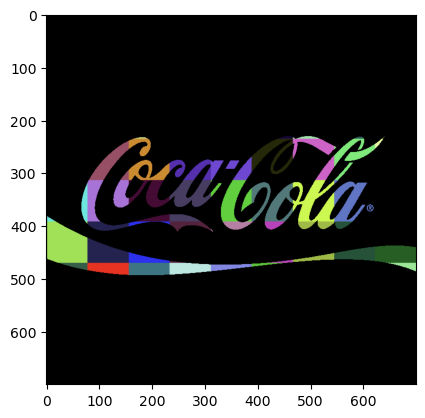

In [20]:
# Create colorful background "behind" the logo lettering
img_background = cv2.bitwise_and(img_background_rgb, img_background_rgb, mask=img_mask)
plt.imshow(img_background);

### Isolate foreground from image

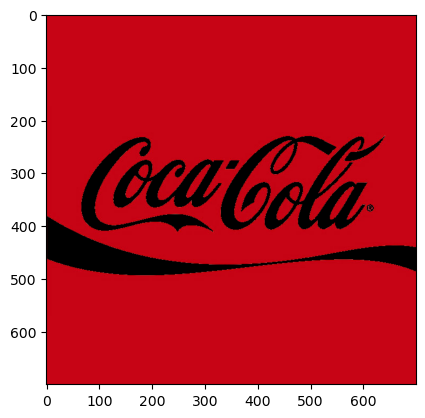

In [21]:
# Isolate foreground (red from original image) using the inverse mask
img_foreground = cv2.bitwise_and(img_rgb, img_rgb, mask=img_mask_inv)
plt.imshow(img_foreground);

### Result: Merge Foreground and Background

True

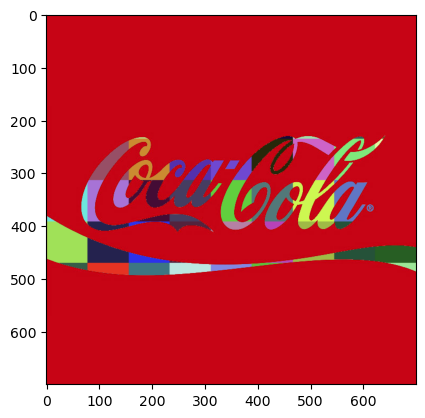

In [22]:
# Add the two previous results obtain the final result
result = cv2.add(img_background, img_foreground)
plt.imshow(result);
cv2.imwrite("logo_final.png", result[:, :, ::-1])